**`CONVOLUTIONAL_NEURAL_NETWORK`**

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import numpy as np
from tensorflow.keras.preprocessing import image
import zipfile

In [2]:
tf.random.set_seed(42)
print('Tensorflow version',tf.__version__)

Tensorflow version 2.19.0


In [5]:
# Download DataSet from KAGGLE.COM
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d omkargurav/face-mask-dataset


Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 83% 135M/163M [00:00<00:00, 1.41GB/s]
100% 163M/163M [00:00<00:00, 1.20GB/s]


In [6]:
with zipfile.ZipFile("face-mask-dataset.zip","r") as zip_ref:
    zip_ref.extractall(".")

In [ ]:
base_dir="data"
print("DataSet Folders: ",os.listdir(base_dir))

DataSet Folders:  ['with_mask', 'without_mask']


In [ ]:
datagen=ImageDataGenerator(rescale=1./255, validation_split=0.2
                          )
train_data=datagen.flow_from_directory(base_dir,
                                          target_size=(224,224),batch_size=32, class_mode='binary', subset='training',seed=42)

Found 6043 images belonging to 2 classes.


In [ ]:
test_data=datagen.flow_from_directory(base_dir,target_size=(224,224),batch_size=32, class_mode='binary', subset='validation',seed=42)

Found 1510 images belonging to 2 classes.


In [ ]:
# craeting the CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,3,activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(16,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 64)   │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,560,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,646,033 (10.09 MB)

 Trainable params: 2,646,033 (10.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(train_data,epochs=10,validation_data=test_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 34/189 ━━━━━━━━━━━━━━━━━━━━ 58s 374ms/step - accuracy: 0.5103 - loss: 0.7997

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 44s 166ms/step - accuracy: 0.6483 - loss: 0.6200 - val_accuracy: 0.9046 - val_loss: 0.2557
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.8797 - loss: 0.2826 - val_accuracy: 0.9311 - val_loss: 0.2138
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.9013 - loss: 0.2582 - val_accuracy: 0.9397 - val_loss: 0.2053
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.9133 - loss: 0.2144 - val_accuracy: 0.9358 - val_loss: 0.1991
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.9292 - loss: 0.1764 - val_accuracy: 0.9397 - val_loss: 0.2285
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.9373 - loss: 0.1491 - val_accuracy: 0.9245 - val_loss: 0.2277
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.9567 - loss: 0.1167 - val_accuracy: 0.9424 - val_loss: 0.1737
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - accuracy: 0.9695 - loss: 0.0844 - val_accura

In [ ]:
#Evaluate
loss,accuracy=model.evaluate(test_data)

print(f"loss: {loss}")
print(f"Accuracy {accuracy}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9298 - loss: 0.2689
loss: 0.23583580553531647
Accuracy 0.9304635524749756


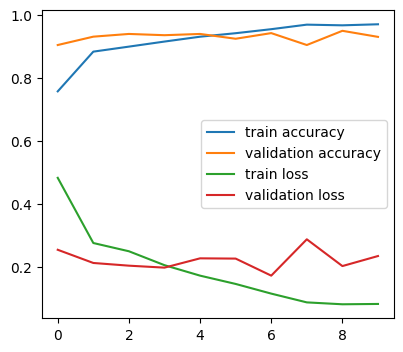

In [ ]:
#plot accuracy and loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step


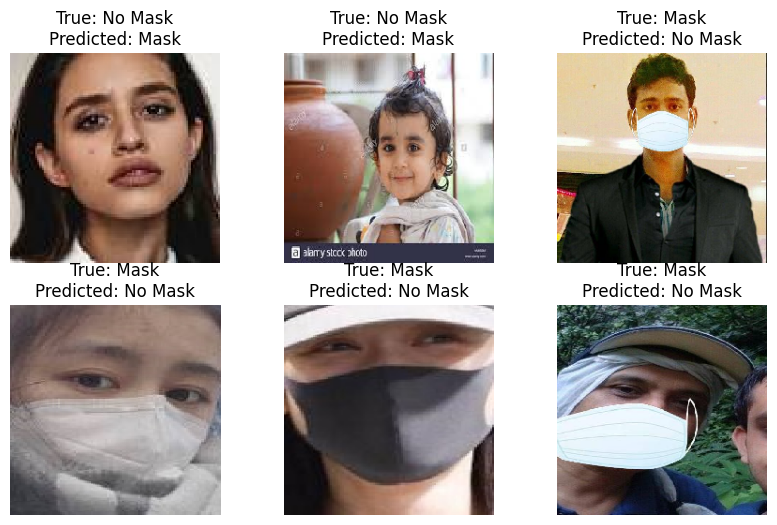

In [ ]:
images,labels=next(test_data)
predictions=model.predict(images)
plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    true_label="Mask" if labels[i]==0 else "No Mask"
    predicted_label="Mask" if predictions[i]>0.5 else "No Mask"
    plt.title(f"True: {true_label}\nPredicted: {predicted_label}")
    plt.axis('off')


Saving download.jpg to download (3).jpg
File uploaded :  /content/download (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediction :  No Mask
Confidence :  97.86902 %


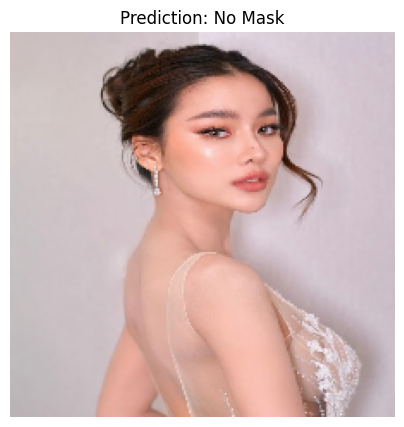

In [ ]:
from tensorflow.keras.preprocessing import image
from google.colab import files
uploaded=files.upload()
for fn in uploaded.keys():
  img_path='/content/'+fn
  print("File uploaded : ",img_path)
  img=image.load_img(img_path,target_size=(224,224))
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)/255.0

  pred=model.predict(img_array)[0][0]
  label="Mask" if pred<0.5 else "No Mask"
  print("Prediction : ",label)
  print("Confidence : ",100*(1-pred) if pred<0.5 else 100*pred,"%")

  plt.figure(figsize=(5,5))
  plt.imshow(img)
  plt.title(f"Prediction: {label}")
  plt.axis("off")
  plt.show()


Saving download.jpg to download (2).jpg
File uploaded: /content/download (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: No Mask
Confidence: 97.86902 %


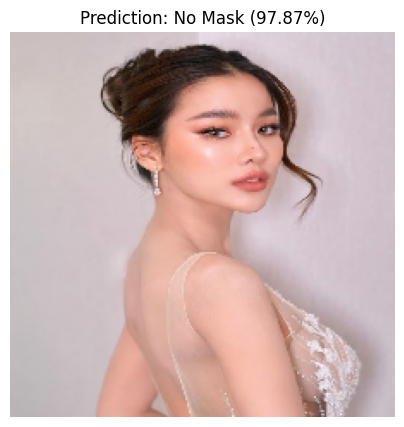

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    print("File uploaded:", img_path)

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Prediction
    pred = model.predict(img_array)[0][0]

    label = "Mask" if pred < 0.5 else "No Mask"
    confidence = 100 * (1 - pred) if pred < 0.5 else 100 * pred

    print("Prediction:", label)
    print("Confidence:", confidence, "%")

    # Display image with result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {label} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()


In [ ]:
model.save('CNN_face_mask_model.keras')
print('Model Saved')